In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
from comparison import tests
import pandas as pd
import numpy as np

In [3]:
from descriptors.edge_descriptors import edge_descriptors_dict
edge_descriptors_dict

{'jaccard_index': functools.partial(<function jaccard_index at 0x0000024C9C048AE0>, normalize=False),
 'jaccard_index_normalized': functools.partial(<function jaccard_index at 0x0000024C9C048AE0>, normalize=True),
 'edge_betweenness': functools.partial(<function edge_betweenness at 0x0000024C9C048B80>, normalize=False),
 'edge_betweenness_normalized': functools.partial(<function edge_betweenness at 0x0000024C9C048B80>, normalize=True),
 'lds': <function descriptors.edge_descriptors.local_degree_score(graph: networkit.graph.Graph) -> numpy.ndarray>,
 'ari': <function descriptors.edge_descriptors.calculate_adjusted_rand_index(graph: networkit.graph.Graph) -> numpy.ndarray>,
 'scan': <function descriptors.edge_descriptors.calculate_scan_structural_similarity_score(graph: networkit.graph.Graph) -> numpy.ndarray>,
 'adamic_adar': <function descriptors.edge_descriptors.calculate_adamic_adar_index(graph: networkit.graph.Graph) -> numpy.ndarray>,
 'katz_index': <function descriptors.edge_descr

In [4]:
list(edge_descriptors_dict.keys())

['jaccard_index',
 'jaccard_index_normalized',
 'edge_betweenness',
 'edge_betweenness_normalized',
 'lds',
 'ari',
 'scan',
 'adamic_adar',
 'katz_index',
 'neighborhood_distance',
 'neighborhood_measure',
 'preferential_attachment',
 'resource_allocation',
 'same_community',
 'total_nieghbors',
 'eigenvector_centrality',
 'cn_quadrangle',
 'cn_triangle']

In [13]:
[(k, ) for k in edge_descriptors_dict.keys()]

[('jaccard_index',),
 ('jaccard_index_normalized',),
 ('edge_betweenness',),
 ('edge_betweenness_normalized',),
 ('lds',),
 ('ari',),
 ('scan',),
 ('adamic_adar',),
 ('katz_index',),
 ('neighborhood_distance',),
 ('neighborhood_measure',),
 ('preferential_attachment',),
 ('resource_allocation',),
 ('same_community',),
 ('total_nieghbors',),
 ('eigenvector_centrality',),
 ('cn_quadrangle',),
 ('cn_triangle',)]

In [16]:
arguments_list = []

for dataset_name in ['graph7c', 'ge10c']:
    # for features in [("moltop",), ("moltop","ltp"), ("moltop", "ldp"), ("moltop", "ltp", "ldp")]:
    for features in [(k, ) for k in edge_descriptors_dict.keys()]:
    
        features = np.array(features)
        arguments_list.append(dict(dataset_name=dataset_name,
                                    features=features,))

In [17]:
tests(arguments_list)

test with {'features': [np.str_('jaccard_index')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('jaccard_index_normalized')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('edge_betweenness')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('edge_betweenness_normalized')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('lds')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('ari')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('scan')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('adamic_adar')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('katz_index')], 'dataset_name': 'graph7c'} parameters existed, skipped
test with {'features': [np.str_('neighborhood_distan

In [18]:
test_data = pd.read_parquet('processed_datasets/table.parquet')
test_data['count'] = test_data['result'].apply(len)

In [19]:
test_data

,features,dataset_name,result,count
0,"[ari, edge_betweenness, scan]",graph7c,[-1],1
0,"[ari, edge_betweenness, jaccard_index, lds, scan]",graph7c,[-1],1
0,"[ari, edge_betweenness, ldp_degree, ldp_max, l...",graph7c,[-1],1
0,"[ari, edge_betweenness, jaccard_index, ldp_deg...",graph7c,[-1],1
0,"[ari, edge_betweenness, scan]",ge10c,"[840, 843, 1040, 1100, 1591, 1594, 1702, 1726,...",206
0,"[ari, edge_betweenness, jaccard_index, lds, scan]",ge10c,"[840, 843, 1040, 1100, 1702, 1726, 1718, 1728,...",124
0,"[ari, edge_betweenness, ldp_degree, ldp_max, l...",ge10c,"[2215, 2254, 2227, 2263, 2280, 2286, 2267, 228...",18
0,"[ari, edge_betweenness, jaccard_index, ldp_deg...",ge10c,"[2280, 2286, 2293, 2306, 2295, 2309]",6
0,[jaccard_index],graph7c,"[4, 20, 9, 21, 47, 8, 23, 24, 26, 43, 49, 109,...",528
0,[jaccard_index_normalized],graph7c,"[216, 228, 100, 296, 305, 308, 393, 399, 387, ...",36


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count'], dtype='object')

c:\Users\Przemek\Documents\Studia\8_semestr\PP\Graph-Isomorphism\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


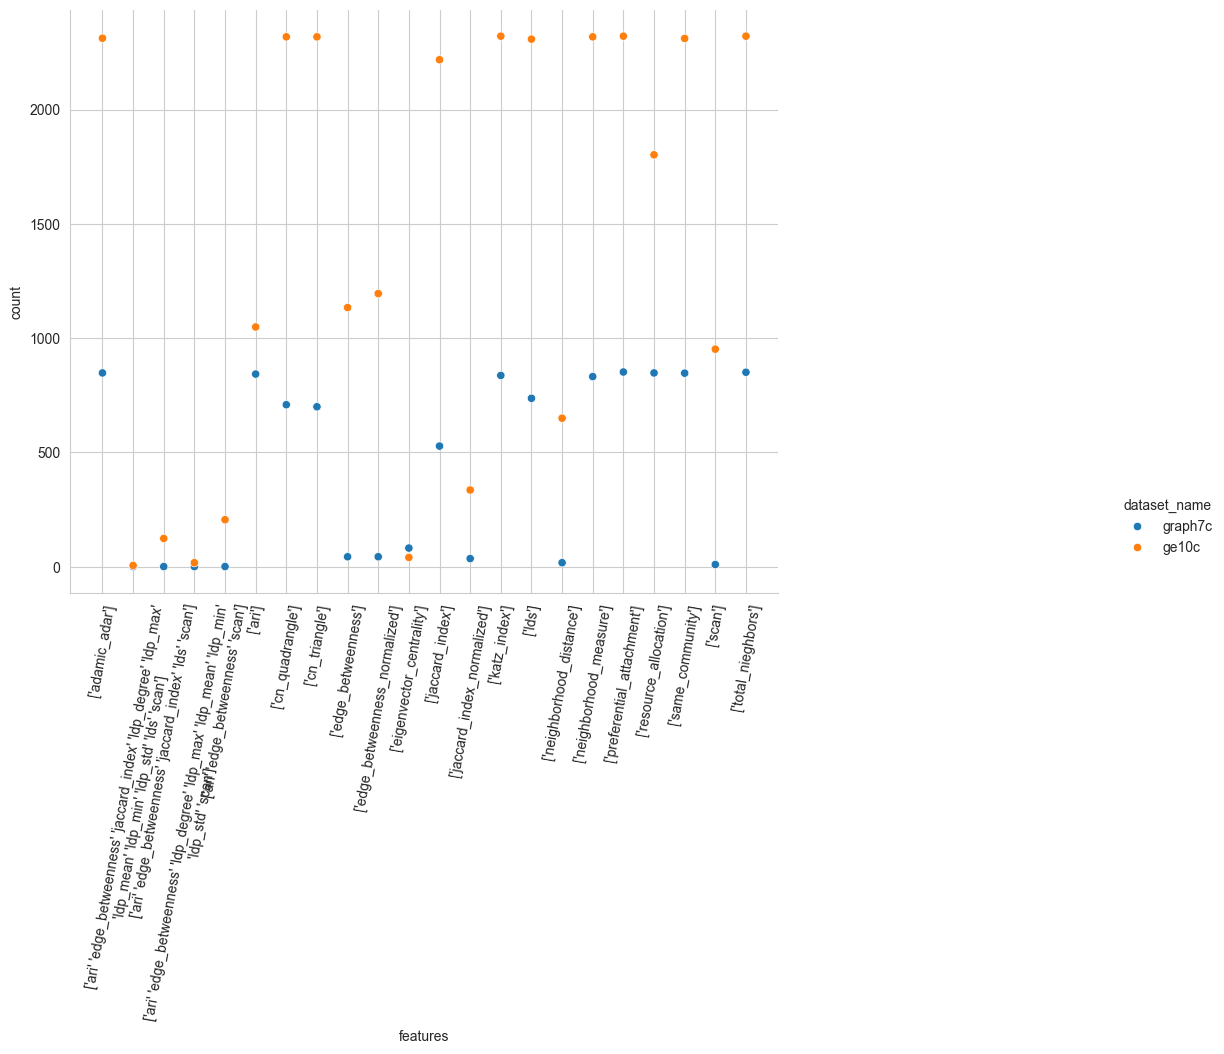

In [21]:
g = sns.pairplot(test_data.drop(columns=['result']), 
             y_vars=['count'],
             x_vars=['features'],
             hue='dataset_name',
             )
fig = plt.gcf()
fig.set_size_inches(15,8)

for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(80)

